In [2]:
!pip install chess

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 41.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for chess: filename=chess-1.11.2-py3-none-any.whl size=147775 sha256=5af07df5faac89638ca21adaff663ffb9ed5f73741a5c474895e742fcfb5037b
  Stored in directory: /root/.cache/pip/wheels/83/1f/4e/8f4300f7dd554eb8de70ddfed96e94d3d030ace10c5b53d447
Successfully built chess


In [4]:
import chess.pgn
import pandas as pd

def filter_player_games(pgn_file, player_name):
    games = []
    with open(pgn_file) as pgn:
        while True:
            game = chess.pgn.read_game(pgn)
            if game is None:
                break
            if game.headers["White"] == player_name or game.headers["Black"] == player_name:
                moves = []
                board = game.board()
                for move in game.mainline_moves():
                    moves.append(board.san(move))
                    board.push(move)
                games.append(" ".join(moves))
    return games

player_name = "Mikhail Tal"
player_games = filter_player_games("Tal_All.pgn", player_name)

with open("player_games.txt", "w") as f:
    for game in player_games:
        f.write(game + "\n")

print(f"Собрано {len(player_games)} партий игрока {player_name}.")

Собрано 2806 партий игрока Mikhail Tal.


In [5]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer, DataCollatorForLanguageModeling
from transformers import Trainer, TrainingArguments
from datasets import Dataset
import torch

# Загрузка предобученной модели и токенизатора
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2")

# Установка pad_token
tokenizer.pad_token = tokenizer.eos_token

# Функция токенизации и чанкования
def tokenize_and_chunk(examples, block_size=128):
    tokenized = tokenizer(examples["text"], truncation=False, padding=False, return_attention_mask=False)
    concatenated = sum(tokenized["input_ids"], [])
    total_length = (len(concatenated) // block_size) * block_size
    input_ids = [concatenated[i:i+block_size] for i in range(0, total_length, block_size)]
    attention_mask = [[1]*block_size for _ in input_ids]
    return {"input_ids": input_ids, "attention_mask": attention_mask}

# Загрузка и подготовка датасета
raw_dataset = Dataset.from_text("player_games.txt")
dataset = raw_dataset.map(
    tokenize_and_chunk,
    batched=True,
    remove_columns=raw_dataset.column_names,
    fn_kwargs={"block_size": 128}
)

# Data collator для языкового моделирования
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

# Аргументы обучения
training_args = TrainingArguments(
    output_dir="./gpt2-chess-style",
    num_train_epochs=3,
    per_device_train_batch_size=4,
    save_steps=500,
    save_total_limit=2,
    logging_dir="./logs",
    logging_steps=100,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=dataset,
)

# Запуск обучения
trainer.train()

# Сохранение модели
model.save_pretrained("./gpt2-chess-style")
tokenizer.save_pretrained("./gpt2-chess-style")
print("Модель успешно обучена и сохранена.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Модель успешно обучена и сохранена.


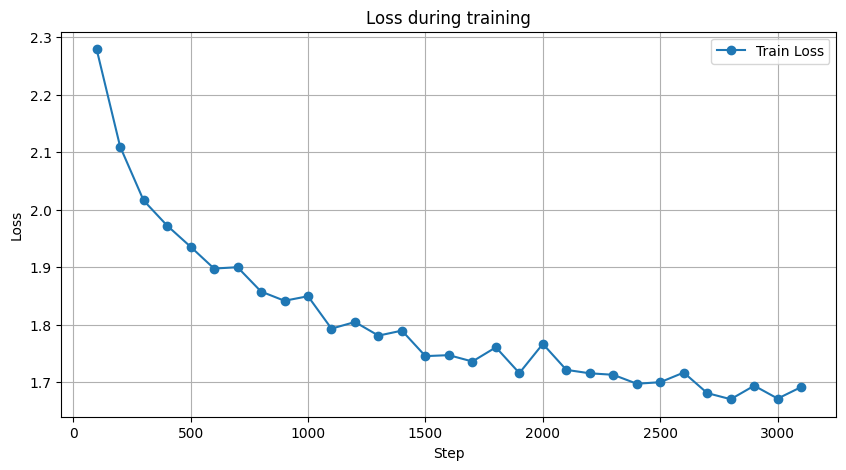

In [6]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history
train_losses = [entry['loss'] for entry in log_history if 'loss' in entry]
steps = [entry['step'] for entry in log_history if 'loss' in entry]

plt.figure(figsize=(10, 5))
plt.plot(steps, train_losses, label='Train Loss', marker='o')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Loss during training')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import chess

def is_valid_move_sequence(moves_san):
    """Проверяет, можно ли разыграть последовательность ходов на доске."""
    board = chess.Board()
    try:
        for san in moves_san.split():
            move = board.parse_san(san)
            board.push(move)
        return True, board
    except Exception:
        return False, None

def generate_game(starting_moves="e4 e5", max_length=50, temperature=0.7, top_p=0.9):
    model = GPT2LMHeadModel.from_pretrained("./gpt2-chess-style/checkpoint-3000")
    tokenizer = GPT2Tokenizer.from_pretrained("./gpt2-chess-style/checkpoint-3000")
    tokenizer.pad_token = tokenizer.eos_token

    input_ids = tokenizer.encode(starting_moves, return_tensors='pt')
    # Переводим модель в режим генерации с сэмплированием
    output = model.generate(
        input_ids,
        max_length=max_length,
        do_sample=True,
        temperature=temperature,
        top_p=top_p,
        pad_token_id=tokenizer.eos_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )
    full_text = tokenizer.decode(output[0], skip_special_tokens=True)

    # Обрезаем текст до первого невалидного хода (если такой есть)
    valid, board = is_valid_move_sequence(full_text)
    if not valid:
        # Пробуем найти самую длинную валидную префиксную последовательность
        words = full_text.split()
        for i in range(len(words), 0, -1):
            valid, _ = is_valid_move_sequence(" ".join(words[:i]))
            if valid:
                full_text = " ".join(words[:i])
                break
    return full_text

# Тест генерации
starting = "e4 e5"
generated = generate_game(starting, max_length=80, temperature=0.8, top_p=0.95)
print("Сгенерированная партия:")
print(generated)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Сгенерированная партия:
e4 e5 Nf3 Nc6 Bb5 a6 Ba4 Nf6 O-O Be7 Re1 b5 Bb3 d6 c3 O-O h3 Na5 Bc2 c5 d4 cxd4 Nxd4 d5 Nbd2


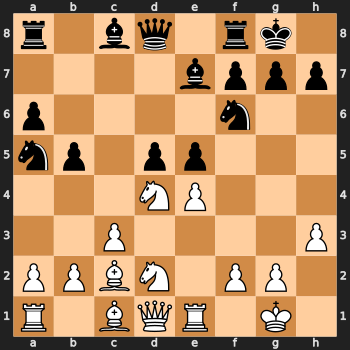

In [13]:
from IPython.display import SVG, display
import chess.svg

_, board = is_valid_move_sequence(generated)
if board:
    display(SVG(chess.svg.board(board=board, size=350)))
else:
    print("Не удалось восстановить доску – последовательность содержит ошибки.")


In [15]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer, Trainer, TrainingArguments, DataCollatorForLanguageModeling
from datasets import Dataset
import math

# Загрузка модели и токенизатора (pad_token уже сохранён)
model = GPT2LMHeadModel.from_pretrained("./gpt2-chess-style/checkpoint-3000")
tokenizer = GPT2Tokenizer.from_pretrained("./gpt2-chess-style/checkpoint-3000")

# Чтение только тестовой выборки (последние 10% строк)
with open("player_games.txt", "r") as f:
    all_games = [line.strip() for line in f if line.strip()]
split = int(0.9 * len(all_games))
test_games = all_games[split:]
print(f"Тестовых партий: {len(test_games)}")

# Создаём Dataset из текста
test_dataset = Dataset.from_dict({"text": test_games})

# Токенизация и чанкование (как при обучении)
def tokenize_and_chunk(examples, block_size=128):
    tokenized = tokenizer(examples["text"], truncation=False, padding=False, return_attention_mask=False)
    concatenated = sum(tokenized["input_ids"], [])
    total_length = (len(concatenated) // block_size) * block_size
    input_ids = [concatenated[i:i+block_size] for i in range(0, total_length, block_size)]
    attention_mask = [[1]*block_size for _ in input_ids]
    return {"input_ids": input_ids, "attention_mask": attention_mask}

tokenized_test = test_dataset.map(
    tokenize_and_chunk,
    batched=True,
    remove_columns=test_dataset.column_names,
    fn_kwargs={"block_size": 128}
)

# Trainer для оценки
trainer = Trainer(
    model=model,
    args=TrainingArguments(output_dir="./eval_results", per_device_eval_batch_size=4, report_to="none"),
    data_collator=DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False),
)

# Вычисление loss и perplexity
eval_loss = trainer.evaluate(eval_dataset=tokenized_test)["eval_loss"]
print(f"Test loss: {eval_loss:.4f}")
print(f"Perplexity: {math.exp(eval_loss):.2f}")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Тестовых партий: 281


Map:   0%|          | 0/281 [00:00<?, ? examples/s]

Test loss: 1.6213
Perplexity: 5.06


In [16]:
print("=== Генерация 3 партий с началом e4 e5 (temperature=0.7) ===\n")
for i in range(3):
    game = generate_game("e4 e5", max_length=70, temperature=0.7, top_p=0.9)
    print(f"{i+1}. {game}\n")

=== Генерация 3 партий с началом e4 e5 (temperature=0.7) ===



Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

1. e4 e5 Nc3 Nc6 Bb5 a6 Ba4 Nf6



Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

2. e4 e5 Nf3 Nc6 Bb5 a6 Ba4 Nf6 O-O Be7 Re1 b5 Bb3 d6 c3 O-O h3 Na5 Bc2 c5 d4 Bb7 Nbd2 cxd4 Nxd4



Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

3. e4 e5 Nf3 Nc6 Bb5 a6 Ba4 Nf6 O-O Be7 Re1 b5 Bb3 d6 c3 O-O h3 Na5 Bc2 c5 d4



In [11]:
from google.colab import drive
import shutil

# Монтируем Google Диск
drive.mount('/content/drive')

# Путь к папке с моделью (измените, если нужно скопировать checkpoint-3000)
source_path = "./gpt2-chess-style"          # или "./gpt2-chess-style/checkpoint-3000"
# Папка назначения на Google Диске
dest_path = "/content/drive/MyDrive/gpt2-chess-style"

# Копируем (перезапишет, если уже существует)
shutil.copytree(source_path, dest_path, dirs_exist_ok=True)

print(f"Модель скопирована в {dest_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Модель скопирована в /content/drive/MyDrive/gpt2-chess-style
